In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("superstore.csv", sep=";")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,3/1/2023,7/1/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...","16,448",2,"0,2","5,5512"
1,2,US-2023-112326,4/1/2023,8/1/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,"3,54",2,"0,8","-5,487"
2,3,US-2023-112326,4/1/2023,8/1/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,"11,784",3,"0,2","4,2717"
3,4,US-2023-112326,4/1/2023,8/1/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,"272,736",3,"0,2","-64,7748"
4,5,US-2023-141817,5/1/2023,12/1/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,"19,536",3,"0,2","4,884"


In [4]:
df["Sales"] = df["Sales"].str.replace(",", ".").astype(float)
df["Profit"] = df["Profit"].str.replace(",", ".").astype(float)

In [5]:
df.dtypes

Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID        object
Customer Name      object
Segment            object
Country/Region     object
City               object
State/Province     object
Postal Code        object
Region             object
Product ID         object
Category           object
Sub-Category       object
Product Name       object
Sales             float64
Quantity            int64
Discount           object
Profit            float64
dtype: object

In [6]:
total_sales = df["Sales"].sum()

print(f"Ventas Totales: ${total_sales:,.2f}")

Ventas Totales: $2,326,534.35


In [7]:
total_profit = df["Profit"].sum()

print(f"Ganancia Total: ${total_profit:,.2f}")

Ganancia Total: $292,296.81


In [8]:
profit_margin = (total_profit / total_sales) * 100

print(f"Margen de Ganancia: {profit_margin:.2f}%")

Margen de Ganancia: 12.56%


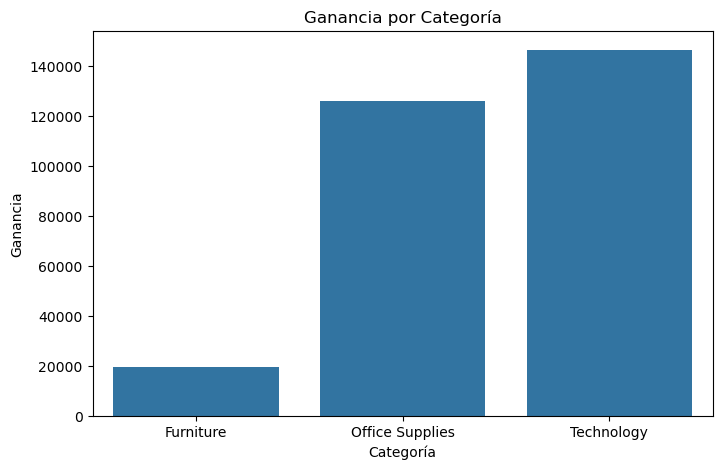

In [9]:
profit_by_category = df.groupby("Category")["Profit"].sum()

plt.figure(figsize=(8,5))

sns.barplot(
    x=profit_by_category.index,
    y=profit_by_category.values
)

plt.title("Ganancia por Categoría")
plt.xlabel("Categoría")
plt.ylabel("Ganancia")

plt.show()

In [10]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

In [11]:
df["Month"] = df["Order Date"].dt.to_period("M")

In [12]:
monthly_sales = df.groupby("Month")["Sales"].sum()

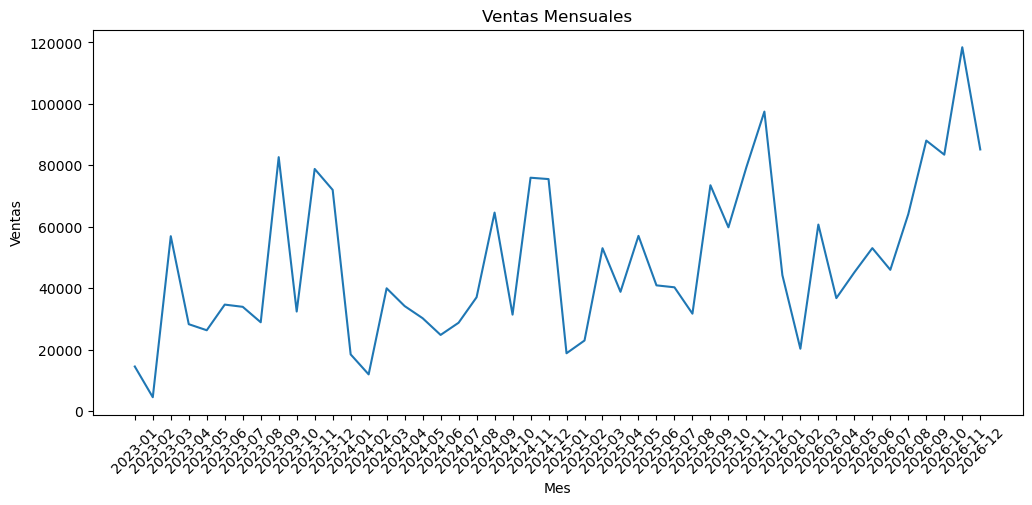

In [13]:
plt.figure(figsize=(12,5))

sns.lineplot(
    x=monthly_sales.index.astype(str),
    y=monthly_sales.values
)

plt.title("Ventas Mensuales")
plt.xlabel("Mes")
plt.ylabel("Ventas")

plt.xticks(rotation=45)

plt.show()

In [14]:
numeric_df = df[["Sales", "Profit", "Discount", "Quantity"]]

In [15]:
correlation = numeric_df.corr()

ValueError: could not convert string to float: '0,2'

In [16]:
df["Discount"] = df["Discount"].astype(str).str.replace(",", ".").astype(float)

In [17]:
numeric_df = df[["Sales", "Profit", "Discount", "Quantity"]]

In [18]:
correlation = numeric_df.corr()

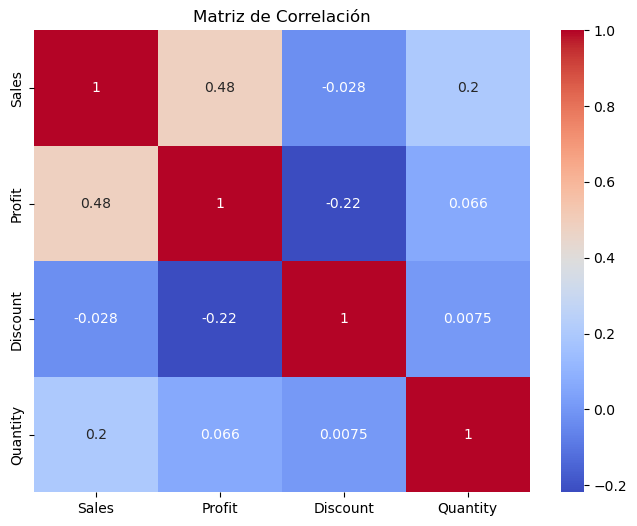

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Matriz de Correlación")

plt.show()

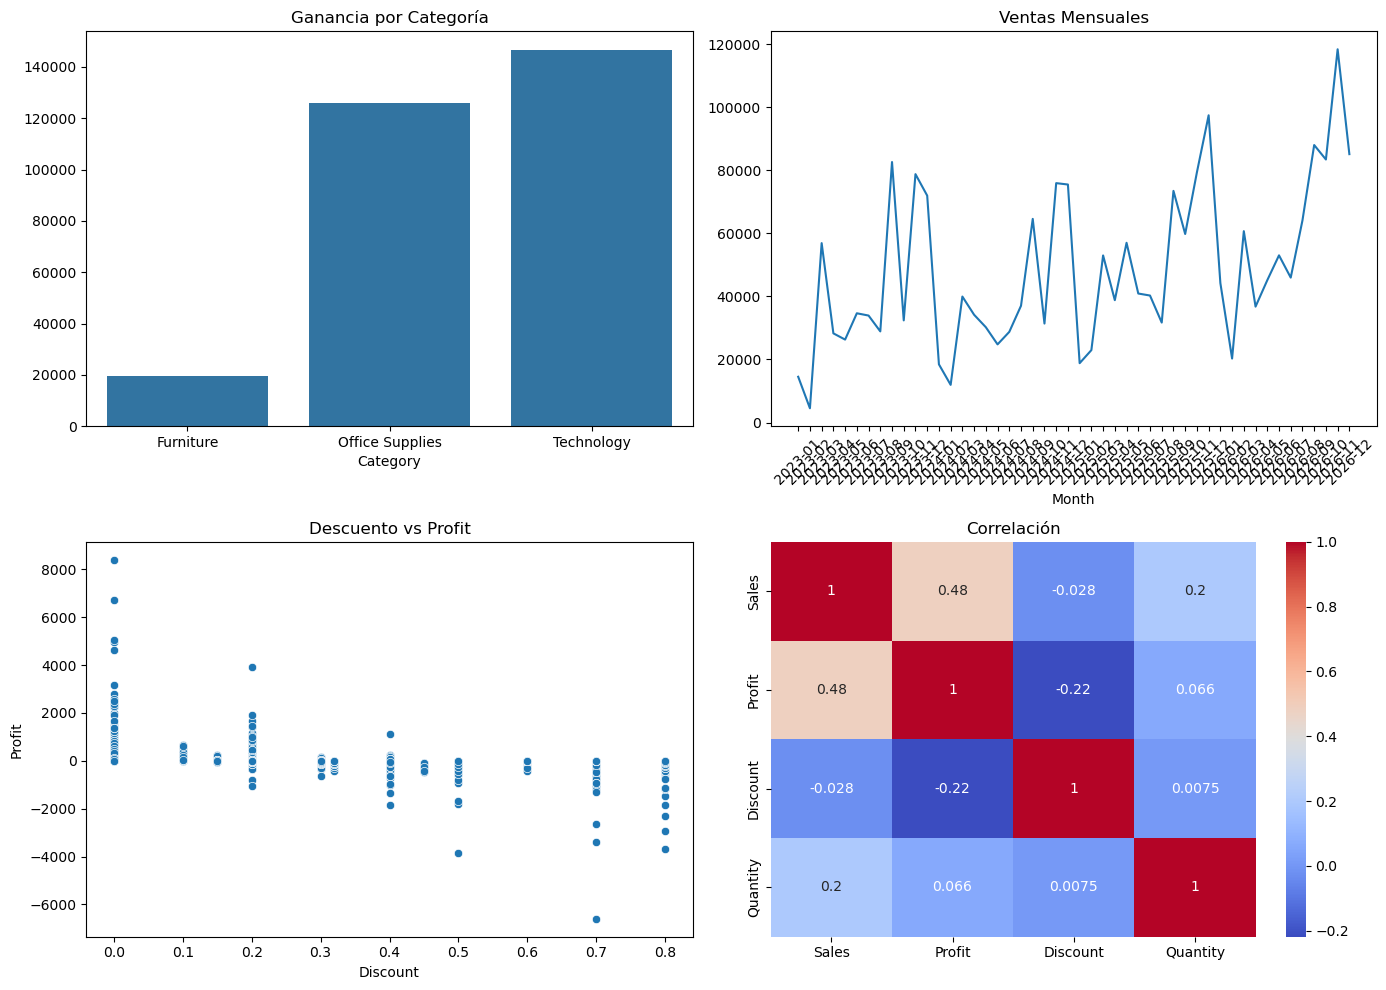

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Profit por categoría
sns.barplot(
    x=profit_by_category.index,
    y=profit_by_category.values,
    ax=axes[0,0]
)

axes[0,0].set_title("Ganancia por Categoría")

# Ventas mensuales
sns.lineplot(
    x=monthly_sales.index.astype(str),
    y=monthly_sales.values,
    ax=axes[0,1]
)

axes[0,1].set_title("Ventas Mensuales")
axes[0,1].tick_params(axis='x', rotation=45)

# Discount vs Profit
sns.scatterplot(
    x=df["Discount"],
    y=df["Profit"],
    ax=axes[1,0]
)

axes[1,0].set_title("Descuento vs Profit")

# Heatmap
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    ax=axes[1,1]
)

axes[1,1].set_title("Correlación")

plt.tight_layout()

plt.show()

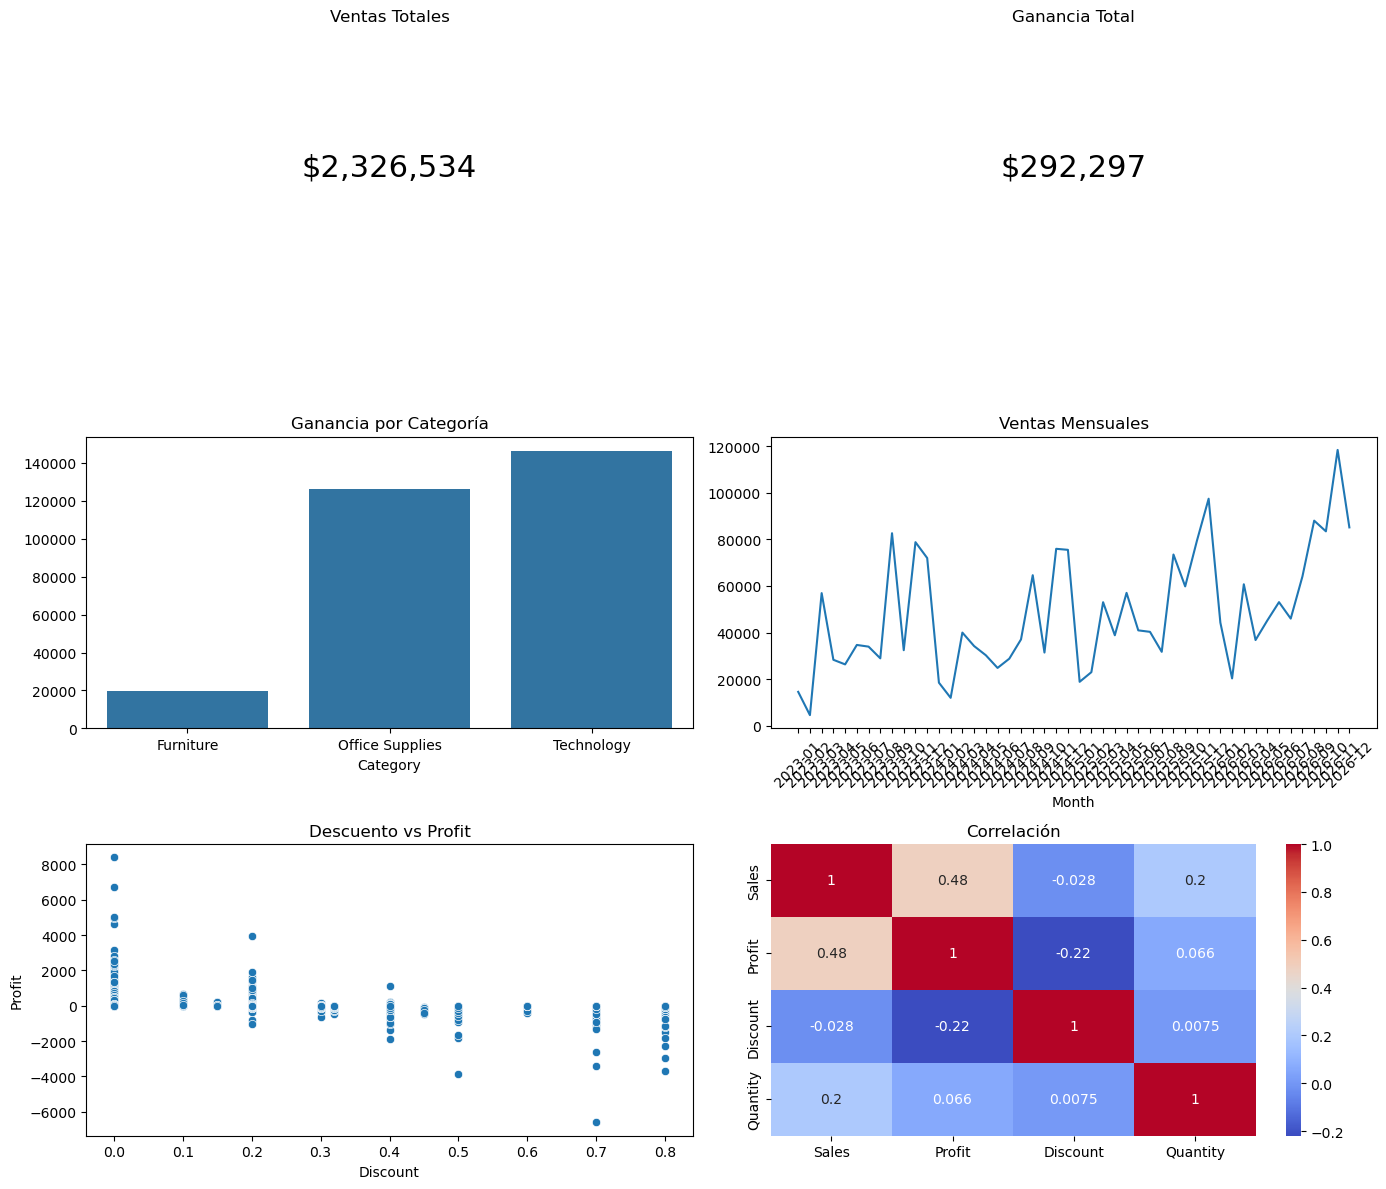

In [21]:
fig, axes = plt.subplots(3, 2, figsize=(14,12))

# KPI Sales
axes[0,0].text(
    0.5,
    0.5,
    f"${total_sales:,.0f}",
    fontsize=22,
    ha='center'
)

axes[0,0].set_title("Ventas Totales")
axes[0,0].axis('off')

# KPI Profit
axes[0,1].text(
    0.5,
    0.5,
    f"${total_profit:,.0f}",
    fontsize=22,
    ha='center'
)

axes[0,1].set_title("Ganancia Total")
axes[0,1].axis('off')

# Profit por categoría
sns.barplot(
    x=profit_by_category.index,
    y=profit_by_category.values,
    ax=axes[1,0]
)

axes[1,0].set_title("Ganancia por Categoría")

# Ventas mensuales
sns.lineplot(
    x=monthly_sales.index.astype(str),
    y=monthly_sales.values,
    ax=axes[1,1]
)

axes[1,1].set_title("Ventas Mensuales")
axes[1,1].tick_params(axis='x', rotation=45)

# Discount vs Profit
sns.scatterplot(
    x=df["Discount"],
    y=df["Profit"],
    ax=axes[2,0]
)

axes[2,0].set_title("Descuento vs Profit")

# Heatmap
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    ax=axes[2,1]
)

axes[2,1].set_title("Correlación")

plt.tight_layout()

plt.show()